<font size=8>Chapter 2: Array </font>

数组的遍历 485、495、414、628

统计数组中的元素 645、697、448、442、41、274

数组的改变、移动 453、665、283

二维数组及滚动数组 118、119、661、598、419

数组的旋转 189、396

特定顺序遍历二维数组  54、59、498

二维数组变换 566、48、73、289

前缀和数组 303、304、238

subarray: a slice or a contiguous (consecutive) portion of an original array

# Prefix Sum （前缀和）

One dimension


-  method one
```
nums = [3, 1, 4, 1, 5, 9]
prefix = [0]
for n in nums:
    prefix.append(prefix[-1] + n)
# prefix is now: [0, 3, 4, 8, 9, 14, 23]
```
-  method two
```
from itertools import accumulate
prefix_sums = list(accumulate(nums, initial=0))
```

In [49]:
from collections import Counter
from itertools import accumulate

two dimension: 

```
matrix = [[0 for _ in range(cols)] for _ in range(rows)]
matrix = [[0]*(cols) for _ in range(rows)]

prefix[i+1][j+1]= prefix[i][j+1] + prefix[i+1][j] - prefix[i][j] + grid[i][j]

```
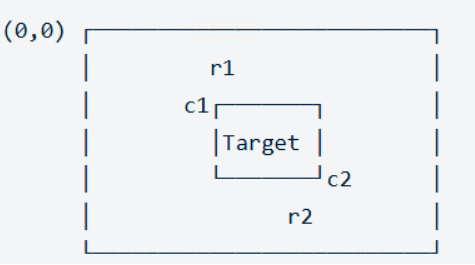


$\text{Sum}=prefix[r_{2}+1][c_{2}+1]-prefix[r_{1}][c_{2}+1]-prefix[r_{2}+1][c_{1}]+prefix[r_{1}][c_{1}]$

## Leetcode 303. Range Sum Query - Immutable

Given an integer array nums, handle multiple queries of the following type:

Calculate the sum of the elements of nums between indices left and right inclusive where left <= right.
Implement the NumArray class:

NumArray(int[] nums) Initializes the object with the integer array nums.
int sumRange(int left, int right) Returns the sum of the elements of nums between indices left and right inclusive (i.e. nums[left] + nums[left + 1] + ... + nums[right]).
 

- Example 1:

Input
["NumArray", "sumRange", "sumRange", "sumRange"]
[[[-2, 0, 3, -5, 2, -1]], [0, 2], [2, 5], [0, 5]]
Output
[null, 1, -1, -3]

Explanation
```
NumArray numArray = new NumArray([-2, 0, 3, -5, 2, -1]);
numArray.sumRange(0, 2); // return (-2) + 0 + 3 = 1
numArray.sumRange(2, 5); // return 3 + (-5) + 2 + (-1) = -1
numArray.sumRange(0, 5); // return (-2) + 0 + 3 + (-5) + 2 + (-1) = -3
```

In [50]:
class NumArray:
    def __init__(self, nums):
        self.prefix_sum = list(accumulate(nums, initial=0))
    def sumRange(self, left, right):
        return self.prefix_sum[right+1] - self.prefix_sum[left]

In [51]:
numArray = NumArray([-2, 0, 3, -5, 2, -1])
numArray.sumRange(0, 2)

1

In [52]:
numArray.sumRange(2, 5)

-1

In [53]:
numArray.sumRange(0, 5)

-3

In [35]:
class NumArray:
    def __init__(self,nums):
        self.prefix = [0] 
        for num in nums:
            self.prefix.append(self.prefix[-1]+num)
        print(self.prefix)
    def sumRange(self, left, right):        
        return self.prefix[right+1] - self.prefix[left]

In [36]:
numArray = NumArray([-2, 0, 3, -5, 2, -1])
numArray.sumRange(0, 2)

[0, -2, -2, 1, -4, -2, -3]


1

In [37]:
numArray.sumRange(2, 5)

-1

In [38]:
numArray.sumRange(0, 5)

-3

## Leetcode 304. Range Sum Query 2D - Immutable (Medium)

Given a 2D matrix matrix, handle multiple queries of the following type:

Calculate the sum of the elements of matrix inside the rectangle defined by its upper left corner (row1, col1) and lower right corner (row2, col2).
Implement the NumMatrix class:

NumMatrix(int[][] matrix) Initializes the object with the integer matrix matrix.
int sumRegion(int row1, int col1, int row2, int col2) Returns the sum of the elements of matrix inside the rectangle defined by its upper left corner (row1, col1) and lower right corner (row2, col2).
You must design an algorithm where sumRegion works on O(1) time complexity.

- Example 1:

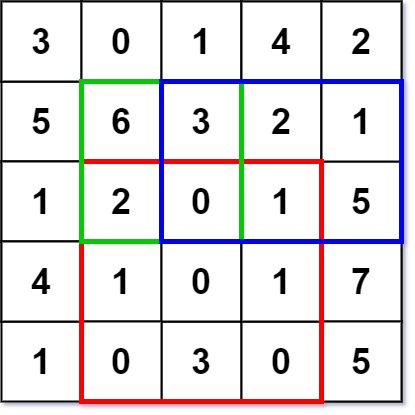

Input
["NumMatrix", "sumRegion", "sumRegion", "sumRegion"]
[[[[3, 0, 1, 4, 2], [5, 6, 3, 2, 1], [1, 2, 0, 1, 5], [4, 1, 0, 1, 7], [1, 0, 3, 0, 5]]], [2, 1, 4, 3], [1, 1, 2, 2], [1, 2, 2, 4]]

Output
[null, 8, 11, 12]

Explanation
```
NumMatrix numMatrix = new NumMatrix([[3, 0, 1, 4, 2], [5, 6, 3, 2, 1], [1, 2, 0, 1, 5], [4, 1, 0, 1, 7], [1, 0, 3, 0, 5]]);
numMatrix.sumRegion(2, 1, 4, 3); // return 8 (i.e sum of the red rectangle)
numMatrix.sumRegion(1, 1, 2, 2); // return 11 (i.e sum of the green rectangle)
numMatrix.sumRegion(1, 2, 2, 4); // return 12 (i.e sum of the blue rectangle)
```

In [73]:
class NumMatrix:
    def __init__(self, matrix):
        rows, cols = len(matrix), len(matrix[0])
        self.prefix_sum = [[0] * (rows+1) for _ in range(cols+1)]
        for i, row in enumerate(matrix):
            for j, value in enumerate(row):
                self.prefix_sum[i+1][j+1] = (self.prefix_sum[i+1][j] + self.prefix_sum[i][j+1] -
                self.prefix_sum[i][j] + value)
    def sumRegion(self, row1, col1, row2, col2):
        return (self.prefix_sum[row2+1][col2+1] +  self.prefix_sum[row1][col1] - 
               self.prefix_sum[row2+1][col1] - self.prefix_sum[row1][col2+1])

In [74]:
numMatrix = NumMatrix([[3, 0, 1, 4, 2], [5, 6, 3, 2, 1], [1, 2, 0, 1, 5], [4, 1, 0, 1, 7], [1, 0, 3, 0, 5]])

In [75]:
numMatrix.sumRegion(2, 1, 4, 3)

8

In [76]:
numMatrix.sumRegion(1, 1, 2, 2)

11

In [77]:
numMatrix.sumRegion(1, 2, 2, 4)

12

In [44]:
class NumMatrix:
    def __init__(self, matrix):
        row, col = len(matrix), len(matrix[0])
        self.prefix_sum = [[0]*(col+1) for _ in range(row+1)]
        for i, row in enumerate(matrix):
            for j, value in enumerate(row):
                self.prefix_sum[i+1][j+1] = (self.prefix_sum[i][j+1] + self.prefix_sum[i+1][j] 
                - self.prefix_sum[i][j] + value)
    
    def sumRegion(self, row1, col1, row2, col2):
        return (self.prefix_sum[row2+1][col2+1] + self.prefix_sum[row1][col1] - self.prefix_sum[row1][col2+1]
                - self.prefix_sum[row2+1][col1])

In [45]:
numMatrix = NumMatrix([[3, 0, 1, 4, 2], [5, 6, 3, 2, 1], [1, 2, 0, 1, 5], [4, 1, 0, 1, 7], [1, 0, 3, 0, 5]])

In [46]:
numMatrix.sumRegion(2, 1, 4, 3)

8

In [47]:
numMatrix.sumRegion(1, 1, 2, 2)

11

In [48]:
numMatrix.sumRegion(1, 2, 2, 4)

12

## Leetcode 1480. Running Sum of 1d Array

Description:
Given an array nums. We define a running sum of an array as runningSum[i] = sum(nums[0]…nums[i]).

Return the running sum of nums.

- Example 1:
Input: nums = [1,2,3,4]

Output: [1,3,6,10]

Explanation:
Running sum is obtained as follows: [1, 1+2, 1+2+3, 1+2+3+4].

- Example 2:
Input: nums = [1,1,1,1,1]

Output: [1,2,3,4,5]

Explanation:
Running sum is obtained as follows: [1, 1+1, 1+1+1, 1+1+1+1, 1+1+1+1+1].

- Example 3:
Input: nums = [3,1,2,10,1]

Output: [3,4,6,16,17]

In [11]:
def runningSum(nums):
    n = len(nums)
    result = [0] * (n)
    accu_sum = 0
    for index, num in enumerate(nums):
        accu_sum += num
        result[index] = accu_sum
    return result

In [12]:
nums = [1,2,3,4]
runningSum(nums)

[1, 3, 6, 10]

In [14]:
nums = [1,1,1,1,1]
runningSum(nums)

[1, 2, 3, 4, 5]

In [13]:
nums = [3,1,2,10,1]
runningSum(nums)

[3, 4, 6, 16, 17]

## Leetcode 724. Find Pivot Index

Given an array of integers nums, calculate the pivot index of this array.

The pivot index is the index where the sum of all the numbers strictly to the left of the index is equal to the sum of all the numbers strictly to the index's right.

If the index is on the left edge of the array, then the left sum is 0 because there are no elements to the left. This also applies to the right edge of the array.

Return the leftmost pivot index. If no such index exists, return -1.

- Example 1:

Input: nums = [1,7,3,6,5,6]
Output: 3

Explanation:
The pivot index is 3.
Left sum = nums[0] + nums[1] + nums[2] = 1 + 7 + 3 = 11
Right sum = nums[4] + nums[5] = 5 + 6 = 11
- Example 2:

Input: nums = [1,2,3]
Output: -1
Explanation:
There is no index that satisfies the conditions in the problem statement.
- Example 3:

Input: nums = [2,1,-1]
Output: 0
Explanation:
The pivot index is 0.
Left sum = 0 (no elements to the left of index 0)
Right sum = nums[1] + nums[2] = 1 + -1 = 0

In [9]:
def pivotIndex(nums):
    prefix = [0]
    n = len(nums)
    for num in nums:
        prefix.append(prefix[-1] + num)
    for index, value in enumerate(prefix[:n]):
        if value == prefix[-1]-prefix[index+1]:
            return index
        
    return -1

In [10]:
nums = [1,7,3,6,5,6] 
pivotIndex(nums)

3

In [11]:
nums = [1,2,3]
pivotIndex(nums)

-1

In [12]:
nums = [2,1,-1]
pivotIndex(nums)

0

## Leetcode 1524. Number of Sub-arrays With Odd Sum (Medium)

Given an array of integers arr, return the number of subarrays with an odd sum.
Since the answer can be very large, return it modulo 109 + 7.

- Example 1:

Input: arr = [1,3,5]
Output: 4
Explanation: All subarrays are [[1],[1,3],[1,3,5],[3],[3,5],[5]]
All sub-arrays sum are [1,4,9,3,8,5].
Odd sums are [1,9,3,5] so the answer is 4.
- Example 2:

Input: arr = [2,4,6]
Output: 0
Explanation: All subarrays are [[2],[2,4],[2,4,6],[4],[4,6],[6]]
All sub-arrays sum are [2,6,12,4,10,6].
All sub-arrays have even sum and the answer is 0.
- Example 3:

Input: arr = [1,2,3,4,5,6,7]
Output: 16

In [22]:
def numberOfSubarray(arr):
    prefix_sum = 0
    n = len(arr)
    parity_count = [1, 0]
    result = 0
    for num in arr:
        prefix_sum += num
        current_parity = prefix_sum & 1
        opposite_parity = current_parity ^ 1
        result += parity_count[opposite_parity]
        parity_count[current_parity] += 1
    return result

In [23]:
arr = [1,3,5]
numberOfSubarray(arr)

4

In [24]:
arr = [2,4,6]
numberOfSubarray(arr)

0

In [25]:
arr = [1,2,3,4,5,6,7]
numberOfSubarray(arr)

16

## Leetcode 1749. Maximum Absolute Sum of Any Subarray (Medium)

You are given an integer array nums. The absolute sum of a subarray [numsl, numsl+1, ..., numsr-1, numsr] is abs(numsl + numsl+1 + ... + numsr-1 + numsr).

Return the maximum absolute sum of any (possibly empty) subarray of nums.

Note that abs(x) is defined as follows:

If x is a negative integer, then abs(x) = -x.
If x is a non-negative integer, then abs(x) = x.
 

- Example 1:

Input: nums = [1,-3,2,3,-4]
Output: 5

Explanation: The subarray [2,3] has absolute sum = abs(2+3) = abs(5) = 5.

- Example 2:

Input: nums = [2,-5,1,-4,3,-2]
Output: 8

Explanation: The subarray [-5,1,-4] has absolute sum = abs(-5+1-4) = abs(-8) = 8.

In [19]:
def maxAbsoluteSum(nums):
    n = len(nums)
    prefix_sum = [0] * (n+1)
    premax, premin = 0, 0
    for i in range(n):
        prefix_sum[i+1] = prefix_sum[i]+nums[i]
        
        premax = max(premax, prefix_sum[i])
        premin = min(premin, prefix_sum[i])

    if premin >= 0:
        return premax
    if premax <= 0:
        return abs(premin)
    return premax-premin

In [20]:
nums = [1,-3,2,3,-4]
maxAbsoluteSum(nums)

5

In [21]:
nums = [2,-5,1,-4,3,-2]
maxAbsoluteSum(nums)

8

## Leetcode 560. Subarray Sum Equals K (Medium)

Given an array of integers nums and an integer k, return the total number of subarrays whose sum equals to k.

A subarray is a contiguous non-empty sequence of elements within an array.

- Example 1:

Input: nums = [1,1,1], k = 2
Output: 2
- Example 2:

Input: nums = [1,2,3], k = 3
Output: 2

In [78]:
def subarraySumEqualsK(nums, k):
    n = len(nums)
    sum_counter = Counter({0:1})
    current_sum = 0
    result = 0
    for num in nums:
        current_sum += num
        if current_sum-k in sum_counter:
            result += sum_counter[current_sum-k]
        sum_counter[current_sum] += 1
    return result

In [79]:
nums = [1,1,1]
k=2
subarraySumEqualsK(nums, k)

2

In [80]:
nums =  [1,2,3]
k=3
subarraySumEqualsK(nums, k)

2

In [20]:
def subSumEqualK(nums, k):
    sum_counter = Counter({0:1})
    result = 0
    currenct_sum = 0
    for num in nums:
        currenct_sum += num
        result += sum_counter[currenct_sum-k]
        sum_counter[currenct_sum] += 1
    return result

In [21]:
nums = [1,1,1]
k=2
subSumEqualK(nums, k)

2

In [22]:
nums =  [1,2,3]
k=3
subSumEqualK(nums, k)

2

## Leetcode 930. Binary Subarrays With Sum (Medium)

Given a binary array nums and an integer goal, return the number of non-empty subarrays with a sum goal.

A subarray is a contiguous part of the array.
- Example 1:

Input: nums = [1,0,1,0,1], goal = 2
Output: 4

Explanation: The 4 subarrays are bolded and underlined below:

$[\underline{1,0,1},0,1]$
$[\underline{1,0,1,0},1]$
$[1,\underline{0,1,0,1}]$
$[1,0,\underline{1,0,1}]$

- Example 2:

Input: nums = [0,0,0,0,0], goal = 0
Output: 15

In [62]:
def binarySubarraysWithSum(nums, goal):
    sum_counter = Counter({0:1})
    result = 0
    currenct_sum = 0
    for num in nums:
        currenct_sum += num
        result += sum_counter[currenct_sum-goal]
        sum_counter[currenct_sum] += 1
    return result

In [63]:
nums = [1,0,1,0,1]
goal = 2
binarySubarraysWithSum(nums, goal)

4

In [64]:
nums = [0,0,0,0,0]
goal = 0
binarySubarraysWithSum(nums, goal)

15

## Leetcode 325. Maximum Size Subarray Sum Equals k (Medium)
Given an array nums and a target value k, find the maximum length of a subarray that sums to k. If there isn't one, return 0 instead.

Note:
The sum of the entire nums array is guaranteed to fit within the 32-bit signed integer range.

- Example 1:

Input: nums = [1, -1, 5, -2, 3], k = 3
Output: 4
Explanation: The subarray [1, -1, 5, -2] sums to 3 and is the longest.

- Example 2:

Input: nums = [-2, -1, 2, 1], k = 1
Output: 2 
Explanation: The subarray [-1, 2] sums to 1 and is the longest.

In [40]:
from collections import Counter
def maxSubSum(nums, k):
    sum_counter = Counter({0:-1})
    maxLength = 0
    currenct_sum = 0
    for index, num in enumerate(nums):
        currenct_sum += num
        if (currenct_sum-k) in sum_counter:
            length = index - sum_counter[currenct_sum-k]
            maxLength = max(maxLength, length)
        else: 
            if currenct_sum not in sum_counter:
                sum_counter[currenct_sum] = index
    return maxLength

In [41]:
nums =  [1, -1, 5, -2, 3]
k = 3 
maxSubSum(nums, k)

4

In [42]:
nums = [-2, -1, 2, 1]
k = 1 
maxSubSum(nums, k)

2

## Leetcode 523. Continuous Subarray Sum (Medium)

A good subarray is a subarray where:

its length is at least two, and
the sum of the elements of the subarray is a multiple of k.
Note that:

A subarray is a contiguous part of the array.
An integer x is a multiple of k if there exists an integer n such that x = n * k. 0 is always a multiple of k.

- Example 1:

Input: nums = [23,2,4,6,7], k = 6
Output: true
Explanation: [2, 4] is a continuous subarray of size 2 whose elements sum up to 6.

- Example 2:

Input: nums = [23,2,6,4,7], k = 6
Output: true
Explanation: [23, 2, 6, 4, 7] is an continuous subarray of size 5 whose elements sum up to 42.
42 is a multiple of 6 because 42 = 7 * 6 and 7 is an integer.

- Example 3:

Input: nums = [23,2,6,4,7], k = 13
Output: false

In [5]:
def contSubSum(nums, k):
    sum_counter = Counter({0:-1})
    sum_remaining = 0
    total_sum = 0
    for index, num in enumerate(nums):
        sum_remaining = (sum_remaining + num) % k
        if sum_remaining not in sum_counter:
            sum_counter[sum_remaining] = index
        elif index - sum_counter[sum_remaining] > 1:
            return True
        
    return False

In [6]:
nums =  [23,2,4,6,7]
k = 6
contSubSum(nums, k)

True

In [7]:
nums = [23,2,6,4,7]
k = 6
contSubSum(nums, k)

True

In [8]:
nums = [23,2,6,4,7]
k = 13
contSubSum(nums, k)

False

## Leetcode 525. Contiguous Array (Medium)

Given a binary array nums, return the maximum length of a contiguous subarray with an equal number of 0 and 1.

- Example 1:

Input: nums = [0,1]
Output: 2
Explanation: [0, 1] is the longest contiguous subarray with an equal number of 0 and 1.
- Example 2:

Input: nums = [0,1,0]
Output: 2
Explanation: [0, 1] (or [1, 0]) is a longest contiguous subarray with equal number of 0 and 1.
- Example 3:

Input: nums = [0,1,1,1,1,1,0,0,0]
Output: 6
Explanation: [1,1,1,0,0,0] is the longest contiguous subarray with equal number of 0 and 1.

In [7]:
def contiguousArray(nums):
    sum_index = {0: -1}
    accum_sum = 0
    max_length = 0
    for index, value in enumerate(nums):
        if value == 0:
            value = -1
        accum_sum += value
        if accum_sum in sum_index:
            max_length = max(max_length, index - sum_index[accum_sum])
        else:
            sum_index[accum_sum] = index
    return max_length

In [8]:
nums = [0,1]
contiguousArray(nums)

2

In [9]:
nums = [0,1,0]
contiguousArray(nums)

2

In [10]:
nums = [0,1,1,1,1,1,0,0,0]
contiguousArray(nums)

6

## Leetcode 238. Product of Array Except Self (Medium)

Given an integer array nums, return an array answer such that answer[i] is equal to the product of all the elements of nums except nums[i].

The product of any prefix or suffix of nums is guaranteed to fit in a 32-bit integer.

You must write an algorithm that runs in O(n) time and without using the division operation.

- Example 1:

Input: nums = [1,2,3,4]
Output: [24,12,8,6]

- Example 2:

Input: nums = [-1,1,0,-3,3]
Output: [0,0,9,0,0]

In [1]:
def productArray(nums):
    n = len(nums)
    prefix, post =  [0]*n, [0]*n
    prefix[0]= nums[0]
    for i in range(1, n):
        prefix[i]= prefix[i-1]*nums[i]
    post[n-1] = nums[n-1]
    for i in range(n-2, -1, -1):
        post[i]= post[i+1] * nums[i]
    result = [0]*n
    result[0]= post[1]
    result[n-1] = prefix[n-2]
    for i in range(1, n-1):
        result[i] = prefix[i-1] * post[i+1]
    return result

In [2]:
nums = [1,2,3,4]
productArray(nums)

[24, 12, 8, 6]

In [3]:
nums = [-1,1,0,-3,3]
productArray(nums)

[0, 0, 9, 0, 0]

# Difference Array （差分数组）

https://www.cnblogs.com/jzssuanfa/p/19236331

差分数组（Difference Array）是一种用于高效处理数组区间增量操作的数据结构或技巧。它的核心思想是将原始数组的区间修改操作转换为差分数组的端点修改操作，从而将时间复杂度从 O(n) 降低到 O(1)。

为什么有用？区间修改操作
差分数组最大的威力在于处理对原始数组某个区间内所有元素同时加上（或减去）一个常数 k​ 的操作。

- 原始方法：​​ 如果要给 arr的区间 [l, r]（包含 l和 r）的每个元素都加上 k，需要遍历该区间内的所有元素（l到 r），时间复杂度为 ​O(n)​​（n 是区间长度）。

- 差分数组方法：​​ 只需要修改差分数组 diff的两个元素​：
```
diff[l] += k

if (r + 1 < n) diff[r + 1] -= k（如果 r + 1没有超出数组边界）
```
- 原理：​​

    - 修改 diff[l] += k：根据还原公式 arr[i] = arr[i-1] + diff[i]，这个操作会导致从位置 l开始，​之后所有位置的 arr[i]在计算时都额外加上了 k​（因为 diff[l]变大了 k，这个 k会传递到 arr[l], arr[l+1], arr[l+2], ...）。

    - 修改 diff[r + 1] -= k（如果 r + 1 < n）：这个操作是为了抵消掉区间 [r+1, n-1]上额外加上的 k。当还原到 arr[r+1]时，diff[r+1]减少了 k，使得 arr[r+1] = arr[r] + (diff[r+1] - k)。由于 arr[r]已经被加了 k（来自第一步的影响），arr[r+1]的计算变成了 (arr[r] + k) + (diff[r+1] - k) = arr[r] + diff[r+1]，正好是原始值加上 diff[r+1]，消除了 k的影响。之后的位置同理。

- 结果：​​ 只有区间 [l, r]内的元素在还原时被加上了 k，区间外的元素不受影响。

- 操作步骤总结
    - 初始化：​​ 根据原始数组 arr构造差分数组 diff。

    - 区间修改：​​ 当需要对 arr的区间 [l, r]增加 k时：
        ```
        diff[l] += k

        if (r + 1 < n) diff[r + 1] -= k

        (时间复杂度 O(1))
        ```

    - 查询（还原）：​​ 当需要知道修改后的 arr[i]的值时，或者需要得到整个修改后的数组时，对差分数组 diff求前缀和得到 arr。

    (查询单个元素 O(1) - 如果维护了前缀和数组；还原整个数组 O(n))

- 优点

    - 区间修改效率高：​​ 将 O(n) 的区间修改操作降低到 O(1)。

    - 实现简单：​​ 概念清晰，代码实现容易。

- 缺点

    - 单点或区间查询效率低：​​ 查询单个元素或区间和需要 O(n) 时间还原前缀和（除非额外维护前缀和数组）。如果查询非常频繁，可能需要结合树状数组或线段树等更高级的数据结构。

- 应用场景
    差分数组特别适用于以下情况：

    - 大量区间修改操作：​​ 问题需要对数组进行多次区间增减操作。

    - 最后统一查询：​​ 所有修改操作完成后，才需要查询最终结果（只需还原一次）。

    - 离线处理：​​ 可以预先记录所有修改操作，最后一次性应用差分并还原。

```
diff[i] = arr[i]- arr[i-1]
arr[i] = arr[i-1] + diff[i]

```

## Leetcode 370. Range Addition (Medium)
Assume you have an array of length n initialized with all 0's and are given k update operations.

Each operation is represented as a triplet: [startIndex, endIndex, inc] which increments each element of subarray A[startIndex ... endIndex] (startIndex and endIndex inclusive) with inc.

Return the modified array after all k operations were executed.

- Example 
Input: length = 5, updates = [[1,3,2],[2,4,3],[0,2,-2]]
Output: [-2,0,3,5,3]

Explanation:

Initial state:
[0,0,0,0,0]

After applying operation [1,3,2]:
[0,2,2,2,0]

After applying operation [2,4,3]:
[0,2,5,5,3]

After applying operation [0,2,-2]:
[-2,0,3,5,3]

In [26]:
def getModifiedArray(n, updates):
    diff = [0] * n
    for i in range(len(updates)):
        low = updates[i][0]
        high = updates[i][1]
        c = updates[i][2]
        diff[low] += c
        if (high+1)<n:
            diff[high+1] -= c
        result = [0]*n
        result[0]=diff[0]
    for i in range(1, n):
        result[i] = result[i-1] + diff[i]
    return result

In [27]:
length = 5
updates = [[1,3,2],[2,4,3],[0,2,-2]]
getModifiedArray(length, updates)

[-2, 0, 3, 5, 3]

## Leetcode 1109. Corporate Flight Bookings (Medium)

There are n flights that are labeled from 1 to n.

You are given an array of flight bookings bookings, where bookings[i] = [firsti, lasti, seatsi] represents a booking for flights firsti through lasti (inclusive) with seatsi seats reserved for each flight in the range.

Return an array answer of length n, where answer[i] is the total number of seats reserved for flight i.

- Example 1:

Input: bookings = [[1,2,10],[2,3,20],[2,5,25]], n = 5
Output: [10,55,45,25,25]
```
Explanation:
Flight labels:        1   2   3   4   5
Booking 1 reserved:  10  10
Booking 2 reserved:      20  20
Booking 3 reserved:      25  25  25  25
Total seats:         10  55  45  25  25
Hence, answer = [10,55,45,25,25]



```
- Example 2:

Input: bookings = [[1,2,10],[2,2,15]], n = 2
Output: [10,25]
```
Explanation:
Flight labels:        1   2
Booking 1 reserved:  10  10
Booking 2 reserved:      15
Total seats:         10  25
Hence, answer = [10,25]
```

In [ ]:
Flight labels:        1   2   3   4   5
Booking 1 reserved:  10  10
Booking 2 reserved:      20  20
Booking 3 reserved:      25  25  25  25
Total seats:         10  55  45  25  25
Hence, answer = [10,55,45,25,25]

In [ ]:
low =1, high= 2, diff[0]=0, diff[1]= 10, diff[2]= 0, diff[3]= -10
arr[i] = arr[i-1]+diff[i]


In [99]:
def flightBooking(bookings, n):
    diff = [0]* (n)
    for i in range(len(bookings)):
        low = bookings[i][0]
        high = bookings[i][1]
        c = bookings[i][2]
        diff[low-1] += c
        if (high) < n:
            diff[high] -= c
    result = [0]* (n)
    result[0] = diff[0]
    for i in range(1, n):
        result[i] = result[i-1] + diff[i]
    return result

In [100]:
bookings = [[1,2,10],[2,3,20],[2,5,25]]
n = 5
flightBooking(bookings, n)

[10, 55, 45, 25, 25]

In [101]:
bookings =[[3,3,5],[1,3,20],[1,2,15]]
n=3
flightBooking(bookings, n)

[35, 35, 25]

In [34]:
def flightBooking(bookings, n):
    diff = [0]*(n+1)
    for i in range(len(bookings)):
        low = bookings[i][0]
        high = bookings[i][1]
        c = bookings[i][2]
        diff[low] += c
        if (high+1)<n:
            diff[high+1] -= c
    result = [0] *(n+1)
    result[0] = diff[0]
    for i in range(1, n+1):
        result[i] = result[i-1] + diff[i]
    return result[1:]

In [35]:
bookings = [[1,2,10],[2,3,20],[2,5,25]]
n = 5
flightBooking(bookings, n)

[10, 55, 45, 25, 25]

In [36]:
bookings = [[1,2,10],[2,2,15]]
n = 2
flightBooking(bookings, n)

[10, 25]

## Leetcode 1094. Car Pooling (Medium)

There is a car with capacity empty seats. The vehicle only drives east (i.e., it cannot turn around and drive west).

You are given the integer capacity and an array trips where trips[i] = [numPassengersi, fromi, toi] indicates that the ith trip has numPassengersi passengers and the locations to pick them up and drop them off are fromi and toi respectively. The locations are given as the number of kilometers due east from the car's initial location.

Return true if it is possible to pick up and drop off all passengers for all the given trips, or false otherwise.

- Example 1:

Input: trips = [[2,1,5],[3,3,7]], capacity = 4
Output: false
- Example 2:

Input: trips = [[2,1,5],[3,3,7]], capacity = 5
Output: true

In [70]:
def carPooling(trips, capacity):
    max_location = max(trip[2] for trip in trips)
    diff = [0] *(max_location + 1)
    for num_passengers, from_location, to_location in trips:
        diff[from_location] += num_passengers
        diff[to_location] -= num_passengers
    return all(passenger_count <= capacity for passenger_count in accumulate(diff))

In [71]:
trips = [[2,1,5],[3,3,7]]
capacity = 4
carPooling(trips, capacity)

False

In [72]:
trips = [[2,1,5],[3,3,7]]
capacity = 5
carPooling(trips, capacity)

True

## Leetcode 2536. Increment Submatrices by One (Medium)

You are given a positive integer n, indicating that we initially have an n x n 0-indexed integer matrix mat filled with zeroes.

You are also given a 2D integer array query. For each query[i] = [row1i, col1i, row2i, col2i], you should do the following operation:

Add 1 to every element in the submatrix with the top left corner (row1i, col1i) and the bottom right corner (row2i, col2i). That is, add 1 to mat[x][y] for all row1i <= x <= row2i and col1i <= y <= col2i.
Return the matrix mat after performing every query.

- Example 1:

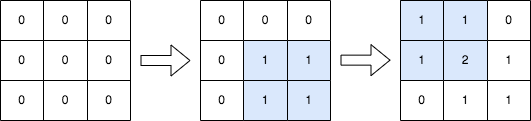

Input: n = 3, queries = [[1,1,2,2],[0,0,1,1]]
Output: [[1,1,0],[1,2,1],[0,1,1]]

Explanation: The diagram above shows the initial matrix, the matrix after the first query, and the matrix after the second query.
    - In the first query, we add 1 to every element in the submatrix with the top left corner (1, 1) and bottom right corner (2, 2).
    - In the second query, we add 1 to every element in the submatrix with the top left corner (0, 0) and bottom right corner (1, 1).

- Example 2:

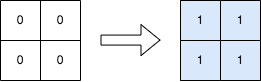

Input: n = 2, queries = [[0,0,1,1]]
Output: [[1,1],[1,1]]

Explanation: The diagram above shows the initial matrix and the matrix after the first query.
- In the first query we add 1 to every element in the matrix.

In [2]:
def incSubMatrices(n, queries):
    diff = [[0] *n for _ in range(n)]
    for r1, c1, r2, c2 in queries:
        for i in range(r1, r2+1):
            diff[i][c1] += 1
            if c2 + 1 < n:
                diff[i][c2+1] -= 1
    result = [[0] *n for _ in range(n)]
    for i in range(n):
        result[i][0] = diff[i][0]
    for i in range(n):
        for j in range(1, n):
            result[i][j] = result[i][j-1]+diff[i][j]
    return result

In [3]:
n = 3
queries = [[1,1,2,2],[0,0,1,1]]
incSubMatrices(n, queries)

[[1, 1, 0], [1, 2, 1], [0, 1, 1]]

In [4]:
n = 2
queries = [[0,0,1,1]]
incSubMatrices(n, queries)

[[1, 1], [1, 1]]

# One dimension Array

## Leetcode 575. Distribute Candies

- Description:
You have n candies, the ith candy is of type candies[i].

You want to distribute the candies equally between a sister and a brother so that each of them gets n / 2 candies (n is even).

The sister loves to collect different types of candies, so you want togive her the maximum number of different types of candies.

Return the maximum number of different types of candies you can give to the sister.

- Example1:
Input: candies =  [1,1,2,3] , Output: 2

Explanation: For example, the sister has candies [2,3] and the brother has candies [1,1].
The sister has two different kinds of candies, the brother has only one kind of candies.

- Example2:
Input: candies = [1,1,2,2,3,3], Output: 3

Explanation: There are three different kinds of candies (1, 2 and 3), and two candies for each kind.Optimal distribution:
The sister has candies [1,2,3]

and the brother has candies [1,2,3], too. The sister has three different kinds of candies.

- Example3:
Input: candies = [1,1], Output: 1

- Example4:
Input: candies = [1,11] , Output: 1

- Example5:
Input: candies = [2,2], Output: 1

- Exmaples6:

Input: candyType = [6,6,6,6], Output: 1


In [ ]:
def distributeCandies(nlist):
    return min(set(nlist), nlist//2)

In [47]:
def distributeCandies(nlist):
    n = len(nlist) // 2
    
    return min(len(set(nlist)), n)

In [48]:
distributeCandies([1,1,2,3])

2

In [49]:
distributeCandies([1,1,2,2,3,3])

3

In [50]:
distributeCandies([1,1])

1

In [52]:
distributeCandies([2,2])

1

In [53]:
distributeCandies([6,6,6,6])

1

## Leetcode 485. Max Consecutive Ones

Given a binary array nums, return the maximum number of consecutive 1's in the array.

- Example 1:

Input: nums = [1,1,0,1,1,1]
Output: 3
Explanation: The first two digits or the last three digits are consecutive 1s. The maximum number of consecutive 1s is 3.
- Example 2:

Input: nums = [1,0,1,1,0,1]
Output: 2

## Leetcode 495. Teemo Attacking

Our hero Teemo is attacking an enemy Ashe with poison attacks! When Teemo attacks Ashe, Ashe gets poisoned for a exactly duration seconds. More formally, an attack at second t will mean Ashe is poisoned during the inclusive time interval [t, t + duration - 1]. If Teemo attacks again before the poison effect ends, the timer for it is reset, and the poison effect will end duration seconds after the new attack.

You are given a non-decreasing integer array timeSeries, where timeSeries[i] denotes that Teemo attacks Ashe at second timeSeries[i], and an integer duration.

Return the total number of seconds that Ashe is poisoned.

- Example 1:

Input: timeSeries = [1,4], duration = 2
Output: 4

Explanation: Teemo's attacks on Ashe go as follows:
- At second 1, Teemo attacks, and Ashe is poisoned for seconds 1 and 2.
- At second 4, Teemo attacks, and Ashe is poisoned for seconds 4 and 5.
Ashe is poisoned for seconds 1, 2, 4, and 5, which is 4 seconds in total.
- Example 2:

Input: timeSeries = [1,2], duration = 2
Output: 3

Explanation: Teemo's attacks on Ashe go as follows:
- At second 1, Teemo attacks, and Ashe is poisoned for seconds 1 and 2.
- At second 2 however, Teemo attacks again and resets the poison timer. Ashe is poisoned for seconds 2 and 3.
Ashe is poisoned for seconds 1, 2, and 3, which is 3 seconds in total.

## Leetcode 414. Third Maximum Number

You are given an integer array nums.

Return the third distinct maximum number in this array. If the third maximum does not exist, return the maximum number.

- Example 1:

Input: nums = [3,2,1]
Output: 1

Explanation:
The first distinct maximum is 3.
The second distinct maximum is 2.
The third distinct maximum is 1.
- Example 2:

Input: nums = [1,2]
Output: 2

Explanation:
The first distinct maximum is 2.
The second distinct maximum is 1.
The third distinct maximum does not exist, so the maximum (2) is returned instead.
- Example 3:

Input: nums = [2,2,3,1]
Output: 1

Explanation:
The first distinct maximum is 3.
The second distinct maximum is 2 (both 2's are counted together since they have the same value).
The third distinct maximum is 1.

## Leetcode 645. Set Mismatch

You have a set of integers s, which originally contains all the numbers from 1 to n. Unfortunately, due to some error, one of the numbers in s got duplicated to another number in the set, which results in repetition of one number and loss of another number.

You are given an integer array nums representing the data status of this set after the error.

Find the number that occurs twice and the number that is missing and return them in the form of an array.

- Example 1:

Input: nums = [1,2,2,4]
Output: [2,3]
- Example 2:

Input: nums = [1,1]
Output: [1,2]

## Leetcode 2460. Apply Operations to an Array

You are given a 0-indexed array nums of size n consisting of non-negative integers.

You need to apply n - 1 operations to this array where, in the ith operation (0-indexed), you will apply the following on the ith element of nums:

If nums[i] == nums[i + 1], then multiply nums[i] by 2 and set nums[i + 1] to 0. Otherwise, you skip this operation.
After performing all the operations, shift all the 0's to the end of the array.

For example, the array [1,0,2,0,0,1] after shifting all its 0's to the end, is [1,2,1,0,0,0].
Return the resulting array.

Note that the operations are applied sequentially, not all at once.

- Example 1:

Input: nums = [1,2,2,1,1,0]
Output: [1,4,2,0,0,0]
Explanation: We do the following operations:
    - i = 0: nums[0] and nums[1] are not equal, so we skip this operation.
    - i = 1: nums[1] and nums[2] are equal, we multiply nums[1] by 2 and change nums[2] to 0. The array becomes [1,4,0,1,1,0].
    - i = 2: nums[2] and nums[3] are not equal, so we skip this operation.
    - i = 3: nums[3] and nums[4] are equal, we multiply nums[3] by 2 and change nums[4] to 0. The array becomes [1,4,0,2,0,0].
    - i = 4: nums[4] and nums[5] are equal, we multiply nums[4] by 2 and change nums[5] to 0. The array becomes [1,4,0,2,0,0].
After that, we shift the 0's to the end, which gives the array [1,4,2,0,0,0].
- Example 2:

Input: nums = [0,1]
Output: [1,0]
Explanation: No operation can be applied, we just shift the 0 to the end.

In [54]:
def applyOp(nums):
    n = len(nums)
    for i in range(n-1):
        if nums[i] == nums[i + 1]:
            nums[i] *= 2
            nums[i + 1] = 0
    current = 0
    for i in range(n):
        if nums[i] != 0:
            nums[current], nums[i] = nums[i], nums[current]
            current += 1
    return nums

In [55]:
nums = [1,2,2,1,1,0]
applyOp(nums)

[1, 4, 2, 0, 0, 0]

In [56]:
nums = [0,1]
applyOp(nums)

[1, 0]

## Leetcode 453. Minimum Moves to Equal Array Elements (Medium)

Given an integer array nums of size n, return the minimum number of moves required to make all array elements equal.

In one move, you can increment n - 1 elements of the array by 1.
- Example 1:

Input: nums = [1,2,3]
Output: 3
Explanation: Only three moves are needed (remember each move increments two elements):
[1,2,3]  =>  [2,3,3]  =>  [3,4,3]  =>  [4,4,4]
- Example 2:

Input: nums = [1,1,1]
Output: 0

## Leetcode 532. K-diff Pairs in an Array (Medium)

Given an array of integers nums and an integer k, return the number of unique k-diff pairs in the array.

A k-diff pair is an integer pair (nums[i], nums[j]), where the following are true:

0 <= i, j < nums.length

i != j

|nums[i] - nums[j]| == k
Notice that |val| denotes the absolute value of val.

- Example 1:

Input: nums = [3,1,4,1,5], k = 2
Output: 2

Explanation: There are two 2-diff pairs in the array, (1, 3) and (3, 5).
Although we have two 1s in the input, we should only return the number of unique pairs.
- Example 2:

Input: nums = [1,2,3,4,5], k = 1
Output: 4

Explanation: There are four 1-diff pairs in the array, (1, 2), (2, 3), (3, 4) and (4, 5).
- Example 3:

Input: nums = [1,3,1,5,4], k = 0
Output: 1
Explanation: There is one 0-diff pair in the array, (1, 1).

In [31]:
def kdiffPair(nums, k):
    unique_set = set()
    seen_set = set()
    for num in nums:
        if num-k in seen_set:
            unique_set.add(num-k)
        if num+k in seen_set:
            unique_set.add(num)
        seen_set.add(num)
    return len(unique_set)

In [32]:
nums = [3,1,4,1,5]
k = 2
kdiffPair(nums, k)

2

In [33]:
nums = [1,2,3,4,5]
k = 1
kdiffPair(nums, k)

4

In [34]:
nums = [1,3,1,5,4]
k = 0
kdiffPair(nums, k)

1

## Leetcode 189. Rotate Array (Medium)

Given an integer array nums, rotate the array to the right by k steps, where k is non-negative.

- Example 1:

Input: nums = [1,2,3,4,5,6,7], k = 3
Output: [5,6,7,1,2,3,4]

Explanation:
rotate 1 steps to the right: [7,1,2,3,4,5,6]
rotate 2 steps to the right: [6,7,1,2,3,4,5]
rotate 3 steps to the right: [5,6,7,1,2,3,4]

- Example 2:

Input: nums = [-1,-100,3,99], k = 2
Output: [3,99,-1,-100]

Explanation: 
rotate 1 steps to the right: [99,-1,-100,3]
rotate 2 steps to the right: [3,99,-1,-100]

In [26]:
def rotateArray(nums, k):
    n = len(nums)
    for i in range(k):
        #print(nums[1:])
        #print(nums[0])
        nums[1:], nums[0] = nums[0:n-1], nums[n-1]
        #print(nums)
    return nums

In [27]:
nums = [1,2,3,4,5,6,7]
k = 3
rotateArray(nums, k)

[5, 6, 7, 1, 2, 3, 4]

In [28]:
nums = [-1,-100,3,99]
k = 2
rotateArray(nums, k)

[3, 99, -1, -100]

## Leetcode 396. Rotate Function (Medium)

You are given an integer array nums of length n.

Assume arrk to be an array obtained by rotating nums by k positions clock-wise. We define the rotation function F on nums as follow:

F(k) = 0 * arrk[0] + 1 * arrk[1] + ... + (n - 1) * arrk[n - 1].
Return the maximum value of F(0), F(1), ..., F(n-1).

The test cases are generated so that the answer fits in a 32-bit integer.

- Example 1:

Input: nums = [4,3,2,6]
Output: 26

Explanation:
```
F(0) = (0 * 4) + (1 * 3) + (2 * 2) + (3 * 6) = 0 + 3 + 4 + 18 = 25
F(1) = (0 * 6) + (1 * 4) + (2 * 3) + (3 * 2) = 0 + 4 + 6 + 6 = 16
F(2) = (0 * 2) + (1 * 6) + (2 * 4) + (3 * 3) = 0 + 6 + 8 + 9 = 23
F(3) = (0 * 3) + (1 * 2) + (2 * 6) + (3 * 4) = 0 + 2 + 12 + 12 = 26
```
So the maximum value of F(0), F(1), F(2), F(3) is F(3) = 26.
- Example 2:

Input: nums = [100]
Output: 0

## Leetcode 1508. Range Sum of Sorted Subarray Sums (Medium)

You are given the array nums consisting of n positive integers. You computed the sum of all non-empty continuous subarrays from the array and then sorted them in non-decreasing order, creating a new array of n * (n + 1) / 2 numbers.

Return the sum of the numbers from index left to index right (indexed from 1), inclusive, in the new array. Since the answer can be a huge number return it modulo 109 + 7.

- Example 1:

Input: nums = [1,2,3,4], n = 4, left = 1, right = 5
Output: 13 
Explanation: All subarray sums are 1, 3, 6, 10, 2, 5, 9, 3, 7, 4. After sorting them in non-decreasing order we have the new array [1, 2, 3, 3, 4, 5, 6, 7, 9, 10]. The sum of the numbers from index le = 1 to ri = 5 is 1 + 2 + 3 + 3 + 4 = 13. 
- Example 2:

Input: nums = [1,2,3,4], n = 4, left = 3, right = 4
Output: 6
Explanation: The given array is the same as example 1. We have the new array [1, 2, 3, 3, 4, 5, 6, 7, 9, 10]. The sum of the numbers from index le = 3 to ri = 4 is 3 + 3 = 6.
- Example 3:

Input: nums = [1,2,3,4], n = 4, left = 1, right = 10
Output: 50

In [ ]:
d

In [ ]:
nums = [1,2,3,4]
n = 4
left = 1
right = 10

## Leetcode 1248. Count Number of Nice Subarrays (Medium)

Given an array of integers nums and an integer k. A continuous subarray is called nice if there are k odd numbers on it.

Return the number of nice sub-arrays.

- Example 1:

Input: nums = [1,1,2,1,1], k = 3
Output: 2
Explanation: The only sub-arrays with 3 odd numbers are [1,1,2,1] and [1,2,1,1].
- Example 2:

Input: nums = [2,4,6], k = 1
Output: 0
Explanation: There are no odd numbers in the array.
- Example 3:

Input: nums = [2,2,2,1,2,2,1,2,2,2], k = 2
Output: 16

## Leetcode 163. Missing Ranges (Medium)

Description
You are given an inclusive range [lower, upper] and a sorted unique integer array nums, where all elements are within the inclusive range.

A number x is considered missing if x is in the range [lower, upper] and x is not in nums.

Return the shortest sorted list of ranges that exactly covers all the missing numbers. That is, no element of nums is included in any of the ranges, and each missing number is covered by one of the ranges.

- Example 1:

Input: nums = [0,1,3,50,75], lower = 0, upper = 99
Output: [[2,2],[4,49],[51,74],[76,99]]

Explanation: The ranges are:
[2,2]
[4,49]
[51,74]
[76,99]

- Example 2:

Input: nums = [-1], lower = -1, upper = -1
Output: []

Explanation: There are no missing ranges since there are no missing numbers.

In [170]:
def missingRange(nlist, lower, upper):
    i = lower
    j = upper
    n = len(nlist)
    result = []
    if n == 0:
        return [[lower, upper]]
    if lower < nlist[0]:
        result.append([lower, nlist[0] -1])
    k = 1
    while k <  n :
        if (nlist[k-1] + 1 ) < nlist[k]:
            result.append([nlist[k-1] + 1, nlist[k] - 1])
        k = k + 1
    
    if upper > nlist[n-1]:
        result.append([nlist[n-1]+1, upper])
    return result

In [171]:
missingRange([0,1,3,50,75], 0, 99)

[[2, 2], [4, 49], [51, 74], [76, 99]]

In [172]:
missingRange([-1], -1, -1)

[]

In [173]:
missingRange([], 1, 2)

[[1, 2]]

In [174]:
missingRange([1,2], 1, 2)

[]

## Leetcode 769. Max Chunks To Make Sorted (Medium)

You are given an integer array arr of length n that represents a permutation of the integers in the range [0, n - 1].

We split arr into some number of chunks (i.e., partitions), and individually sort each chunk. After concatenating them, the result should equal the sorted array.

Return the largest number of chunks we can make to sort the array.

- Example 1:

Input: arr = [4,3,2,1,0]
Output: 1

Explanation:
Splitting into two or more chunks will not return the required result.
For example, splitting into [4, 3], [2, 1, 0] will result in [3, 4, 0, 1, 2], which isn't sorted.
- Example 2:

Input: arr = [1,0,2,3,4]
Output: 4

Explanation:
We can split into two chunks, such as [1, 0], [2, 3, 4].
However, splitting into [1, 0], [2], [3], [4] is the highest number of chunks possible.

In [57]:
def chunksSort(arr):
    chucks_num = 0
    max_num = 0
    for index, value in enumerate(arr):
        max_num = max(max_num, value)
        if index == max_num:
            chucks_num += 1
    return chucks_num

In [58]:
arr = [4,3,2,1,0]
chunksSort(arr)

1

In [59]:
arr = [1,0,2,3,4]
chunksSort(arr)

4

## Leetcode 713. Subarray Product Less Than K (Medium)

Given an array of integers nums and an integer k, return the number of contiguous subarrays where the product of all the elements in the subarray is strictly less than k.

- Example 1:

Input: nums = [10,5,2,6], k = 100
Output: 8

Explanation: The 8 subarrays that have product less than 100 are:
[10], [5], [2], [6], [10, 5], [5, 2], [2, 6], [5, 2, 6]
Note that [10, 5, 2] is not included as the product of 100 is not strictly less than k.

- Example 2:

Input: nums = [1,2,3], k = 0
Output: 0

In [35]:
def subarrayProductLessK(nums, k):
    start_index = 0
    product = 1
    count = 0
    for end_index, num in enumerate(nums):
        product *= num
        while start_index <= end_index and product >= k:
            product //= nums[start_index]
            start_index += 1
        count += end_index - start_index + 1
    return count
        

In [36]:
nums = [10,5,2,6]
k = 100
subarrayProductLessK(nums, k)

8

In [37]:
nums = [1,2,3]
k = 0
subarrayProductLessK(nums, k)

0

## Leetcode 665. Non-decreasing Array (Medium)

Given an array nums with n integers, your task is to check if it could become non-decreasing by modifying at most one element.

We define an array is non-decreasing if nums[i] <= nums[i + 1] holds for every i (0-based) such that (0 <= i <= n - 2).

- Example 1:

Input: nums = [4,2,3]
Output: true
Explanation: You could modify the first 4 to 1 to get a non-decreasing array.
- Example 2:

Input: nums = [4,2,1]
Output: false
Explanation: You cannot get a non-decreasing array by modifying at most one element.

## Leetcode 118. Pascal's Triangle
Given an integer numRows, return the first numRows of Pascal's triangle.

In Pascal's triangle, each number is the sum of the two numbers directly above it as shown:

- Example 1:

Input: numRows = 5
Output: [[1],[1,1],[1,2,1],[1,3,3,1],[1,4,6,4,1]]
- Example 2:

Input: numRows = 1
Output: [[1]]

## Leetcode 119. Pascal's Triangle II
Given an integer rowIndex, return the rowIndexth (0-indexed) row of the Pascal's triangle.

In Pascal's triangle, each number is the sum of the two numbers directly above it as shown:

- Example 1:

Input: rowIndex = 3
Output: [1,3,3,1]
- Example 2:

Input: rowIndex = 0
Output: [1]
- Example 3:

Input: rowIndex = 1
Output: [1,1]

## Leetcode 1920. Build Array from Permutation

Given a zero-based permutation nums (0-indexed), build an array ans of the same length where ans[i] = nums[nums[i]] for each 0 <= i < nums.length and return it.

A zero-based permutation nums is an array of distinct integers from 0 to nums.length - 1 (inclusive).


- Example 1:

Input: nums = [0,2,1,5,3,4]
Output: [0,1,2,4,5,3]

Explanation: The array ans is built as follows: 
ans = [nums[nums[0]], nums[nums[1]], nums[nums[2]], nums[nums[3]], nums[nums[4]], nums[nums[5]]]
    = [nums[0], nums[2], nums[1], nums[5], nums[3], nums[4]]
    = [0,1,2,4,5,3]
- Example 2:

Input: nums = [5,0,1,2,3,4]
Output: [4,5,0,1,2,3]

Explanation: The array ans is built as follows:
ans = [nums[nums[0]], nums[nums[1]], nums[nums[2]], nums[nums[3]], nums[nums[4]], nums[nums[5]]]
    = [nums[5], nums[0], nums[1], nums[2], nums[3], nums[4]]
    = [4,5,0,1,2,3]

## Leetcode 1929. Concatenation of Array

Given an integer array nums of length n, you want to create an array ans of length 2n where ans[i] == nums[i] and ans[i + n] == nums[i] for 0 <= i < n (0-indexed).

Specifically, ans is the concatenation of two nums arrays.

Return the array ans.

- Example 1:

Input: nums = [1,2,1]
Output: [1,2,1,1,2,1]

Explanation: The array ans is formed as follows:
    - ans = [nums[0],nums[1],nums[2],nums[0],nums[1],nums[2]]
    - ans = [1,2,1,1,2,1]
- Example 2:

Input: nums = [1,3,2,1]
Output: [1,3,2,1,1,3,2,1]

Explanation: The array ans is formed as follows:
    - ans = [nums[0],nums[1],nums[2],nums[3],nums[0],nums[1],nums[2],nums[3]]
    - ans = [1,3,2,1,1,3,2,1]

## Leetcode 2089. Find Target Indices After Sorting Array

You are given a 0-indexed integer array nums and a target element target.

A target index is an index i such that nums[i] == target.

Return a list of the target indices of nums after sorting nums in non-decreasing order. If there are no target indices, return an empty list. The returned list must be sorted in increasing order.


- Example 1:

Input: nums = [1,2,5,2,3], target = 2
Output: [1,2]
Explanation: After sorting, nums is [1,2,2,3,5].
The indices where nums[i] == 2 are 1 and 2.
- Example 2:

Input: nums = [1,2,5,2,3], target = 3
Output: [3]
Explanation: After sorting, nums is [1,2,2,3,5].
The index where nums[i] == 3 is 3.
- Example 3:

Input: nums = [1,2,5,2,3], target = 5
Output: [4]
Explanation: After sorting, nums is [1,2,2,3,5].
The index where nums[i] == 5 is 4

# Sorted Array

## Leetcode 628. Maximum Product of Three Numbers

Given an integer array nums, find three numbers whose product is maximum and return the maximum product.
- Example 1:

Input: nums = [1,2,3]
Output: 6

- Example 2:

Input: nums = [1,2,3,4]
Output: 24
- Example 3:

Input: nums = [-1,-2,-3]
Output: -6

In [40]:
import math
def maxProductThreeNumbers(nums):
    nums.sort()
    product_three_largest = nums[-1]* nums[-2] * nums[-3]
    product_first_two_last = nums[-1]* nums[0] * nums[1]
    
    return max(product_three_largest, product_first_two_last)

In [41]:
nums = [1,2,3]
maxProductThreeNumbers(nums)

6

In [42]:
nums = [1,2,3,4]
maxProductThreeNumbers(nums)

24

In [43]:
nums = [-1,-2,-3]
maxProductThreeNumbers(nums)

-6

## Leetcode 1200. Minimum Absolute Difference

Given an array of distinct integers arr, find all pairs of elements with the minimum absolute difference of any two elements.

Return a list of pairs in ascending order(with respect to pairs), each pair [a, b] follows

a, b are from arr
a < b
b - a equals to the minimum absolute difference of any two elements in arr

- Example 1:

Input: arr = [4,2,1,3]
Output: [[1,2],[2,3],[3,4]]

Explanation: The minimum absolute difference is 1. List all pairs with difference equal to 1 in ascending order.

- Example 2:

Input: arr = [1,3,6,10,15]
Output: [[1,3]]

- Example 3:

Input: arr = [3,8,-10,23,19,-4,-14,27]
Output: [[-14,-10],[19,23],[23,27]]

In [ ]:
def 

## Leetcode 1287. Element Appearing More Than 25% In Sorted Array
Given an integer array sorted in non-decreasing order, there is exactly one integer in the array that occurs more than 25% of the time, return that integer.

- Example 1:

Input: arr = [1,2,2,6,6,6,6,7,10]
Output: 6

- Example 2:

Input: arr = [1,1]
Output: 1

## Leetcode 264. Ugly Number II (Medium)

An ugly number is a positive integer whose prime factors are limited to 2, 3, and 5.

Given an integer n, return the nth ugly number.

- Example 1:

Input: n = 10
Output: 12
Explanation: [1, 2, 3, 4, 5, 6, 8, 9, 10, 12] is the sequence of the first 10 ugly numbers.
- Example 2:

Input: n = 1
Output: 1
Explanation: 1 has no prime factors, therefore all of its prime factors are limited to 2, 3, and 5.

## Leetcode 373. Find K Pairs with Smallest Sums (Medium)

You are given two integer arrays nums1 and nums2 sorted in non-decreasing order and an integer k.

Define a pair (u, v) which consists of one element from the first array and one element from the second array.

Return the k pairs (u1, v1), (u2, v2), ..., (uk, vk) with the smallest sums.

- Example 1:

Input: nums1 = [1,7,11], nums2 = [2,4,6], k = 3
Output: [[1,2],[1,4],[1,6]]

Explanation: The first 3 pairs are returned from the sequence: [1,2],[1,4],[1,6],[7,2],[7,4],[11,2],[7,6],[11,4],[11,6]
- Example 2:

Input: nums1 = [1,1,2], nums2 = [1,2,3], k = 2
Output: [[1,1],[1,1]]

Explanation: The first 2 pairs are returned from the sequence: [1,1],[1,1],[1,2],[2,1],[1,2],[2,2],[1,3],[1,3],[2,3]

## Leetcode 360. Sort Transformed Array
Given a sorted array of integers nums and integer values a, b and c. Apply a quadratic function of the form $f(x) = ax^2 + bx + c$ to each element x in the array.Computer Science


The returned array must be in sorted order.

Expected time complexity: O(n)

- Example 1:

Input: nums = [-4,-2,2,4], a = 1, b = 3, c = 5
Output: [3,9,15,33]
- Example 2:

Input: nums = [-4,-2,2,4], a = -1, b = 3, c = 5
Output: [-23,-5,1,7]

## Leetcode 1243. Array Transformation
Given an initial array arr, every day you produce a new array using the array of the previous day.


On the i-th day, you do the following operations on the array of day i-1 to produce the array of day i:

If an element is smaller than both its left neighbor and its right neighbor, then this element is incremented.
If an element is bigger than both its left neighbor and its right neighbor, then this element is decremented.
The first and last elements never change.
After some days, the array does not change. Return that final array.Computer Science

- Example 1:

Input: arr = [6,2,3,4]
Output: [6,3,3,4]
Explanation: 
On the first day, the array is changed from [6,2,3,4] to [6,3,3,4].
No more operations can be done to this array.
- Example 2:

Input: arr = [1,6,3,4,3,5]
Output: [1,4,4,4,4,5]
Explanation: 
On the first day, the array is changed from [1,6,3,4,3,5] to [1,5,4,3,4,5].
On the second day, the array is changed from [1,5,4,3,4,5] to [1,4,4,4,4,5].
No more operations can be done to this array.

## Leetcode 1439. Find the Kth Smallest Sum of a Matrix With Sorted Rows(Hard)

You are given an m x n matrix mat that has its rows sorted in non-decreasing order and an integer k.

You are allowed to choose exactly one element from each row to form an array.

Return the kth smallest array sum among all possible arrays.

- Example 1:

Input: mat = [[1,3,11],[2,4,6]], k = 5
Output: 7
Explanation: Choosing one element from each row, the first k smallest sum are:
[1,2], [1,4], [3,2], [3,4], [1,6]. Where the 5th sum is 7.
- Example 2:

Input: mat = [[1,3,11],[2,4,6]], k = 9
Output: 17
- Example 3:

Input: mat = [[1,10,10],[1,4,5],[2,3,6]], k = 7
Output: 9
Explanation: Choosing one element from each row, the first k smallest sum are:
[1,1,2], [1,1,3], [1,4,2], [1,4,3], [1,1,6], [1,5,2], [1,5,3]. Where the 7th sum is 9.  

# Two dimension Array

## Leetcode 598. Range Addition II

You are given an m x n matrix M initialized with all 0's and an array of operations ops, where ops[i] = [ai, bi] means M[x][y] should be incremented by one for all 0 <= x < ai and 0 <= y < bi.

Count and return the number of maximum integers in the matrix after performing all the operations.

- Example 1:

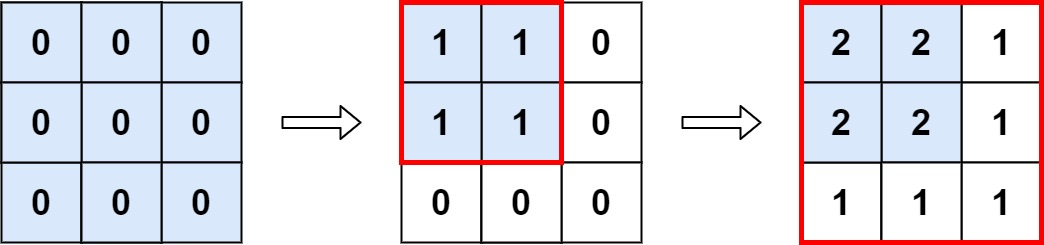

Input: m = 3, n = 3, ops = [[2,2],[3,3]]
Output: 4
Explanation: The maximum integer in M is 2, and there are four of it in M. So return 4.
- Example 2:

Input: m = 3, n = 3, ops = [[2,2],[3,3],[3,3],[3,3],[2,2],[3,3],[3,3],[3,3],[2,2],[3,3],[3,3],[3,3]]
Output: 4
- Example 3:

Input: m = 3, n = 3, ops = []
Output: 9

In [4]:
def rangeAdditionII(m, n, ops):
    min_row = m
    min_col = n
    for row, col in ops:
        min_row = min(row, min_row)
        min_col = min(col, min_col)
    return min_row*min_col

In [5]:
m = 3
n = 3
ops = [[2,2],[3,3]]
rangeAdditionII(m, n, ops)

4

In [6]:
m = 3
n = 3
ops = [[2,2],[3,3],[3,3],[3,3],[2,2],[3,3],[3,3],[3,3],[2,2],[3,3],[3,3],[3,3]]
rangeAdditionII(m, n, ops)

4

In [7]:
m = 3
n = 3
ops = []
rangeAdditionII(m, n, ops)

9

## Leetcode 766. Toeplitz Matrix
Given an m x n matrix, return true if the matrix is Toeplitz. Otherwise, return false.
A matrix is Toeplitz if every diagonal from top-left to bottom-right has the same elements.
- Example 1:

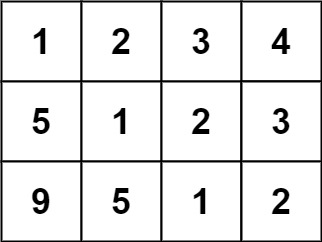

Input: matrix = [[1,2,3,4],[5,1,2,3],[9,5,1,2]]
Output: true

Explanation:
In the above grid, the diagonals are:
"[9]", "[5, 5]", "[1, 1, 1]", "[2, 2, 2]", "[3, 3]", "[4]".
In each diagonal all elements are the same, so the answer is True.
- Example 2:

  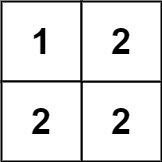

Input: matrix = [[1,2],[2,2]]
Output: false

Explanation: The diagonal "[1, 2]" has different elements.

## Leetcode 661. Image Smoother

An image smoother is a filter of the size 3 x 3 that can be applied to each cell of an image by rounding down the average of the cell and the eight surrounding cells (i.e., the average of the nine cells in the blue smoother). If one or more of the surrounding cells of a cell is not present, we do not consider it in the average (i.e., the average of the four cells in the red smoother).


Given an m x n integer matrix img representing the grayscale of an image, return the image after applying the smoother on each cell of it.

- Example 1:

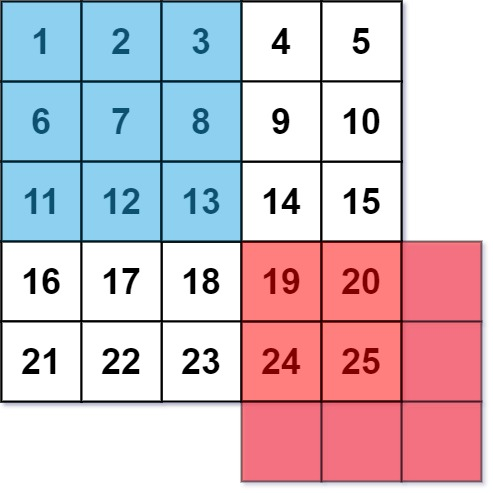

Input: img = [[1,1,1],[1,0,1],[1,1,1]]
Output: [[0,0,0],[0,0,0],[0,0,0]]

Explanation:
```
For the points (0,0), (0,2), (2,0), (2,2): floor(3/4) = floor(0.75) = 0
For the points (0,1), (1,0), (1,2), (2,1): floor(5/6) = floor(0.83333333) = 0
For the point (1,1): floor(8/9) = floor(0.88888889) = 0
```
- Example 2:

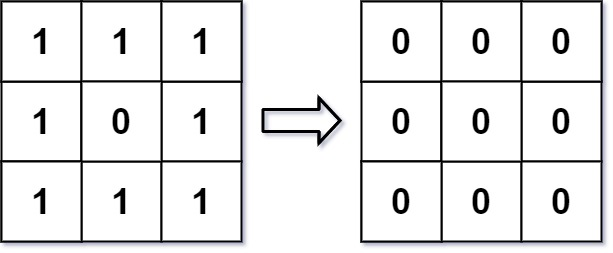

Input: img = [[100,200,100],[200,50,200],[100,200,100]]
Output: [[137,141,137],[141,138,141],[137,141,137]]
Explanation:
```
For the points (0,0), (0,2), (2,0), (2,2): floor((100+200+200+50)/4) = floor(137.5) = 137
For the points (0,1), (1,0), (1,2), (2,1): floor((200+200+50+200+100+100)/6) = floor(141.666667) = 141
For the point (1,1): floor((50+200+200+200+200+100+100+100+100)/9) = floor(138.888889) = 138
```

## Leetcode 566. Reshape the Matrix

In MATLAB, there is a handy function called reshape which can reshape an m x n matrix into a new one with a different size r x c keeping its original data.

You are given an m x n matrix mat and two integers r and c representing the number of rows and the number of columns of the wanted reshaped matrix.

The reshaped matrix should be filled with all the elements of the original matrix in the same row-traversing order as they were.

If the reshape operation with given parameters is possible and legal, output the new reshaped matrix; Otherwise, output the original matrix.

- Example 1:

Input: mat = [[1,2],[3,4]], r = 1, c = 4
Output: [[1,2,3,4]]

- Example 2:

Input: mat = [[1,2],[3,4]], r = 2, c = 4
Output: [[1,2],[3,4]]

In [43]:
def reshapeMatrix(mat, r, c):
    n = len(mat) # row
    m = len(mat[0]) #column
    #print(n, m)
    if r*c != m *n:
        return mat
    new_mat =  [[0 for _ in range(c)] for _ in range(r)]
    result = []
    for i in range(n):
        for j in range(m):
            #print(i, j)
            result.append(mat[i][j])
       
    for i in range(r):
        for j in range(c):
            #print(i,j)
            new_mat[i][j] = result[c*i+j]
    return new_mat
    return

In [44]:
reshapeMatrix([[1,2],[3,4]], 1, 4)

[[1, 2, 3, 4]]

In [46]:
reshapeMatrix([[1,2,3,4]], 2, 2)

[[1, 2], [3, 4]]

## Leetcode 48. Rotate Image (Medium)

You are given an n x n 2D matrix representing an image, rotate the image by 90 degrees (clockwise).

You have to rotate the image in-place, which means you have to modify the input 2D matrix directly. 
DO NOT allocate another 2D matrix and do the rotation.

Example 1:
Input: matrix = [[1,2,3],[4,5,6],[7,8,9]]
Output: [[7,4,1],[8,5,2],[9,6,3]]

Example 2:

Input: matrix = [[5,1,9,11],[2,4,8,10],[13,3,6,7],[15,14,12,16]]
Output: [[15,13,2,5],[14,3,4,1],[12,6,8,9],[16,7,10,11]]


## Leetcode 73. Set Matrix Zeroes (Medium)

Given an m x n integer matrix matrix, if an element is 0, set its entire row and column to 0's.

You must do it in place.
- Example 1:


Input: matrix = [[1,1,1],[1,0,1],[1,1,1]]
Output: [[1,0,1],[0,0,0],[1,0,1]]
- Example 2:


Input: matrix = [[0,1,2,0],[3,4,5,2],[1,3,1,5]]
Output: [[0,0,0,0],[0,4,5,0],[0,3,1,0]]

## Leetcode 289. Game of Life (Medium)

According to Wikipedia's article: "The Game of Life, also known simply as Life, is a cellular automaton devised by the British mathematician John Horton Conway in 1970."

The board is made up of an m x n grid of cells, where each cell has an initial state: live (represented by a 1) or dead (represented by a 0). Each cell interacts with its eight neighbors (horizontal, vertical, diagonal) using the following four rules (taken from the above Wikipedia article):

Any live cell with fewer than two live neighbors dies as if caused by under-population.
Any live cell with two or three live neighbors lives on to the next generation.
Any live cell with more than three live neighbors dies, as if by over-population.
Any dead cell with exactly three live neighbors becomes a live cell, as if by reproduction.
The next state of the board is determined by applying the above rules simultaneously to every cell in the current state of the m x n grid board. In this process, births and deaths occur simultaneously.

Given the current state of the board, update the board to reflect its next state.

Note that you do not need to return anything.

- Example 1:

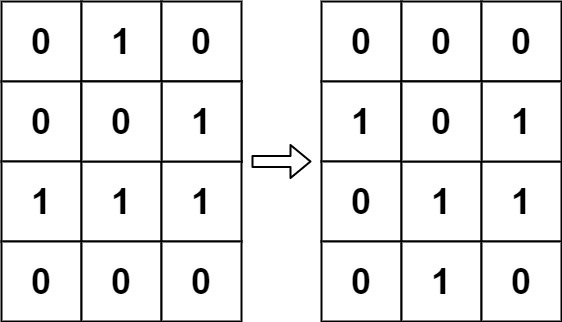

Input: board = [[0,1,0],[0,0,1],[1,1,1],[0,0,0]]
Output: [[0,0,0],[1,0,1],[0,1,1],[0,1,0]]
- Example 2:

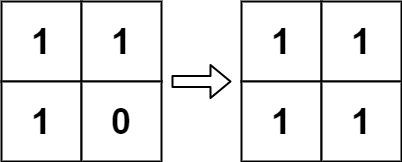

Input: board = [[1,1],[1,0]]
Output: [[1,1],[1,1]]

## Leetcode 54. Spiral Matrix (Medium)

Given an m x n matrix, return all elements of the matrix in spiral order.

- Example 1:

Input: matrix = [[1,2,3],[4,5,6],[7,8,9]]
Output: [1,2,3,6,9,8,7,4,5]
- Example 2:


Input: matrix = [[1,2,3,4],[5,6,7,8],[9,10,11,12]]
Output: [1,2,3,4,8,12,11,10,9,5,6,7]

## Leetcode 59. Spiral Matrix II (Medium)

Given a positive integer n, generate an n x n matrix filled with elements from 1 to n2 in spiral order.

- Example 1:


Input: n = 3
Output: [[1,2,3],[8,9,4],[7,6,5]]
- Example 2:

Input: n = 1
Output: [[1]]

## Leetcode 498. Diagonal Traverse (Medium)

Given an m x n matrix mat, return an array of all the elements of the array in a diagonal order.

 

- Example 1:

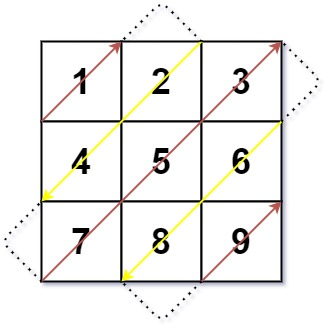

Input: mat = [[1,2,3],[4,5,6],[7,8,9]]
Output: [1,2,4,7,5,3,6,8,9]

- Example 2:

Input: mat = [[1,2],[3,4]]
Output: [1,2,3,4]

## Leetcode 1314. Matrix Block Sum (Medium)

Given a m x n matrix mat and an integer k, return a matrix answer where each answer[i][j] is the sum of all elements mat[r][c] for:

i - k <= r <= i + k,
j - k <= c <= j + k, and
(r, c) is a valid position in the matrix.

- Example 1:

Input: mat = [[1,2,3],[4,5,6],[7,8,9]], k = 1
Output: [[12,21,16],[27,45,33],[24,39,28]]
- Example 2:

Input: mat = [[1,2,3],[4,5,6],[7,8,9]], k = 2
Output: [[45,45,45],[45,45,45],[45,45,45]]

## Leetcode 240. Search a 2D Matrix II (Medium)

Write an efficient algorithm that searches for a value target in an m x n integer matrix matrix. This matrix has the following properties:

Integers in each row are sorted in ascending from left to right.
Integers in each column are sorted in ascending from top to bottom.
 
- Example 1:

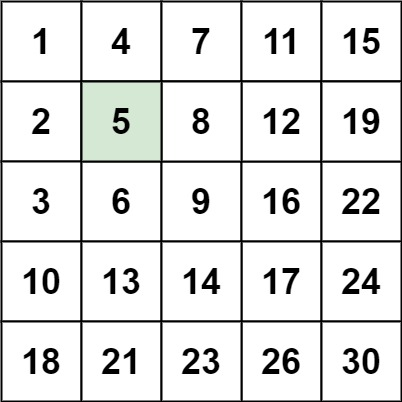

Input: matrix = [[1,4,7,11,15],[2,5,8,12,19],[3,6,9,16,22],[10,13,14,17,24],[18,21,23,26,30]], target = 5
Output: true
- Example 2:

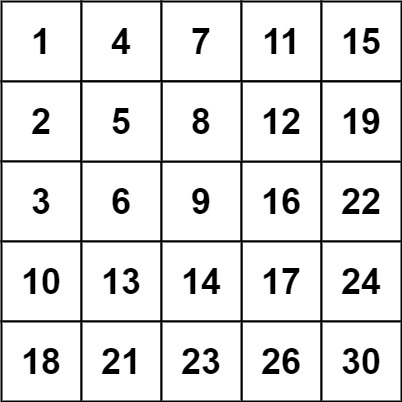

Input: matrix = [[1,4,7,11,15],[2,5,8,12,19],[3,6,9,16,22],[10,13,14,17,24],[18,21,23,26,30]], target = 20
Output: false

## Leetcode 419. Battleships in a Board (Medium)

Given an m x n matrix board where each cell is a battleship 'X' or empty '.', return the number of the battleships on board.

Battleships can only be placed horizontally or vertically on board. In other words, they can only be made of the shape 1 x k (1 row, k columns) or k x 1 (k rows, 1 column), where k can be of any size. At least one horizontal or vertical cell separates between two battleships (i.e., there are no adjacent battleships).

Example 1:

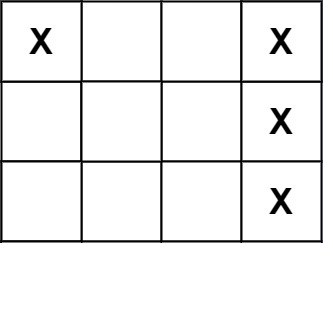

Input: board = [["X",".",".","X"],[".",".",".","X"],[".",".",".","X"]]
Output: 2
Example 2:

Input: board = [["."]]
Output: 0

# Leetcode 891. Sum of Subsequence Widths (Hard)

The width of a sequence is the difference between the maximum and minimum elements in the sequence.

Given an array of integers nums, return the sum of the widths of all the non-empty subsequences of nums. Since the answer may be very large, return it modulo 109 + 7.

A subsequence is a sequence that can be derived from an array by deleting some or no elements without changing the order of the remaining elements. For example, [3,6,2,7] is a subsequence of the array [0,3,1,6,2,2,7].

- Example 1:

Input: nums = [2,1,3]
Output: 6
Explanation: The subsequences are [1], [2], [3], [2,1], [2,3], [1,3], [2,1,3].
The corresponding widths are 0, 0, 0, 1, 1, 2, 2.
The sum of these widths is 6.
- Example 2:

Input: nums = [2]
Output: 0

# Leetcode 65. Valid Number (Hard)

Given a string s, return whether s is a valid number.

For example, all the following are valid numbers: "2", "0089", "-0.1", "+3.14", "4.", "-.9", "2e10", "-90E3", "3e+7", "+6e-1", "53.5e93", "-123.456e789", while the following are not valid numbers: "abc", "1a", "1e", "e3", "99e2.5", "--6", "-+3", "95a54e53".

Formally, a valid number is defined using one of the following definitions:

An integer number followed by an optional exponent.
A decimal number followed by an optional exponent.
An integer number is defined with an optional sign '-' or '+' followed by digits.

A decimal number is defined with an optional sign '-' or '+' followed by one of the following definitions:

Digits followed by a dot '.'.
Digits followed by a dot '.' followed by digits.
A dot '.' followed by digits.
An exponent is defined with an exponent notation 'e' or 'E' followed by an integer number.

The digits are defined as one or more digits.

- Example 1:

Input: s = "0"

Output: true

- Example 2:

Input: s = "e"

Output: false

- Example 3:

Input: s = "."

Output: false

In [ ]:
def validNumber(s):
    if s[0].

# Leetcode 363. Max Sum of Rectangle No Larger Than K (Hard)

Given an m x n matrix matrix and an integer k, return the max sum of a rectangle in the matrix such that its sum is no larger than k.

It is guaranteed that there will be a rectangle with a sum no larger than k.

- Example 1:


Input: matrix = [[1,0,1],[0,-2,3]], k = 2
Output: 2
Explanation: Because the sum of the blue rectangle [[0, 1], [-2, 3]] is 2, and 2 is the max number no larger than k (k = 2).
- Example 2:

Input: matrix = [[2,2,-1]], k = 3
Output: 3

# Leetcode 41. First Missing Positive (Hard)

Given an unsorted integer array nums. Return the smallest positive integer that is not present in nums.

You must implement an algorithm that runs in O(n) time and uses O(1) auxiliary space.

- Example 1:

Input: nums = [1,2,0]
Output: 3
Explanation: The numbers in the range [1,2] are all in the array.

- Example 2:

Input: nums = [3,4,-1,1]
Output: 2
Explanation: 1 is in the array but 2 is missing.

- Example 3:

Input: nums = [7,8,9,11,12]
Output: 1
Explanation: The smallest positive integer 1 is missing.

# Leetcode 798. Smallest Rotation with Highest Score (Hard)

You are given an array nums. You can rotate it by a non-negative integer k so that the array becomes [nums[k], nums[k + 1], ... nums[nums.length - 1], nums[0], nums[1], ..., nums[k-1]]. Afterward, any entries that are less than or equal to their index are worth one point.

For example, if we have nums = [2,4,1,3,0], and we rotate by k = 2, it becomes [1,3,0,2,4]. This is worth 3 points because 1 > 0 [no points], 3 > 1 [no points], 0 <= 2 [one point], 2 <= 3 [one point], 4 <= 4 [one point].
Return the rotation index k that corresponds to the highest score we can achieve if we rotated nums by it. If there are multiple answers, return the smallest such index k.

- Example 1:

Input: nums = [2,3,1,4,0]
Output: 3
Explanation: Scores for each k are listed below: 
k = 0,  nums = [2,3,1,4,0],    score 2
k = 1,  nums = [3,1,4,0,2],    score 3
k = 2,  nums = [1,4,0,2,3],    score 3
k = 3,  nums = [4,0,2,3,1],    score 4
k = 4,  nums = [0,2,3,1,4],    score 3
So we should choose k = 3, which has the highest score.
- Example 2:

Input: nums = [1,3,0,2,4]
Output: 0
Explanation: nums will always have 3 points no matter how it shifts.
So we will choose the smallest k, which is 0.